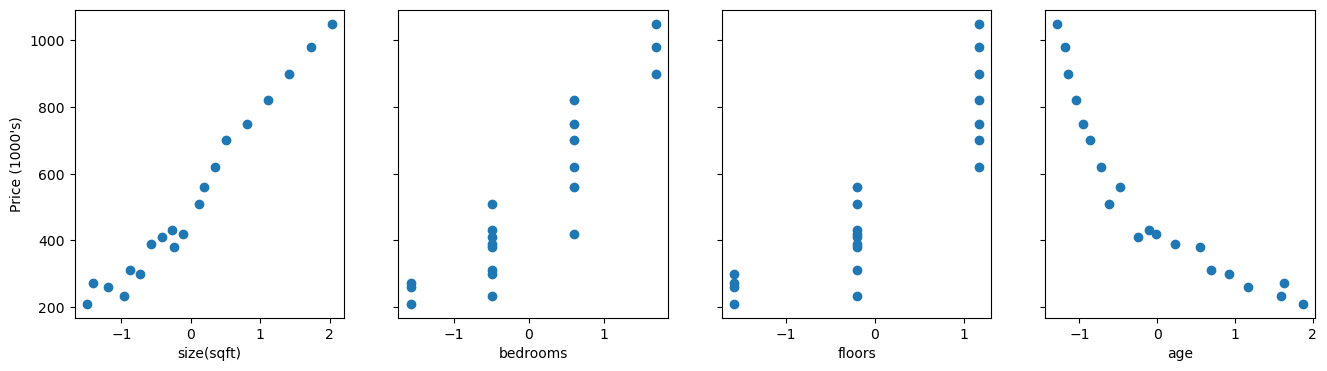

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Input data features: Size(sqft) - Bedrooms - Floors - Age(Years)
x_train = np.array([
    [952,  2, 1, 65],
    [1244, 3, 2, 64],
    [1947, 3, 2, 17],
    [1720, 3, 2, 42],
    [1800, 4, 2, 30],
    [2100, 4, 3, 15],
    [900,  2, 1, 70],
    [1400, 3, 1, 50],
    [1600, 3, 2, 25],
    [2400, 4, 3, 10],
    [3000, 5, 3, 5],
    [1100, 2, 1, 55],
    [1300, 3, 2, 45],
    [2000, 4, 2, 20],
    [2600, 4, 3, 8],
    [3200, 5, 3, 3],
    [1500, 3, 2, 35],
    [1700, 3, 2, 28],
    [2200, 4, 3, 12],
    [2800, 5, 3, 6],
])

# Target data: Price (in units of $1,000s)
y_train = np.array([
    271.5,
    232.0,
    509.8,
    380.0,
    420.0,
    620.0,
    210.0,
    300.0,
    410.0,
    750.0,
    980.0,
    260.0,
    310.0,
    560.0,
    820.0,
    1050.0,
    390.0,
    430.0,
    700.0,
    900.0,
])

x_features = ['size(sqft)','bedrooms','floors','age'] 

# Feature Scaling: Z-Score Normalization
def zscore_normalization(x):
    mu = np.mean(x, axis = 0)
    sigma = np.std(x, axis = 0)
    x_norm = (x - mu) / sigma
    return x_norm, mu, sigma

x_norm, mu, sigma = zscore_normalization(x_train)

fig,ax=plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for i in range(len(ax)):
    ax[i].scatter(x_norm[:, i], y_train)
    ax[i].set_xlabel(x_features[i])
ax[0].set_ylabel("Price (1000's)")
plt.show()




In [6]:
def predict(x, w, b):
    p = np.dot(x, w) + b
    return p

def compute_cost(x, y, w, b):
    m = x.shape[0]
    # np.sum -> same as calculus sum symbol
    return np.sum((predict(x, w, b) - y)**2) / (2*m)

def compute_gradient_derivatives(x, y, w, b):

    m,n = x.shape
    # Initial values of the derivatives
    dJ_dw = np.zeros((n,))
    dJ_db = 0.0


    for i in range(m):
        error = predict(x[i], w, b) - y[i]
        for j in range(n):
            # For each error we need weights to multiply which is x[i, j]
            dJ_dw[j] += error * x[i, j]
        # After taking the derivative nothing left other than error
        dJ_db += error 
    

    dJ_dw = dJ_dw / m
    dJ_db = dJ_db / m

    return dJ_dw, dJ_db

def gradient_descent(x, y, w_in, b_in, alpha, num_iter, gradient_func):
    
    w = w_in.copy()
    b = b_in
    J_history = []

    for i in range(num_iter):

        dJ_dw, dJ_db = gradient_func(x, y, w, b)

        w -= alpha * dJ_dw
        b -= alpha * dJ_db

        if i % 100 == 0:
            cost = compute_cost(x, y, w, b)
            J_history.append(cost)

    return w, b, J_history

Initial cost: 126225.42311490225
Final cost: 899.8708101381619


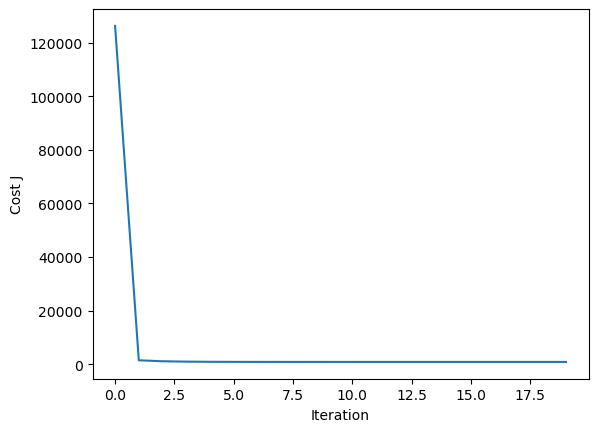

First 5 preds: [182.36923399 288.84651128 563.58641515 483.30780294 464.97307505]
First 5 true : [271.5 232.  509.8 380.  420. ]
MAPE (%): 9.017795074174927


In [21]:
# Initializing variables
m, n = x_norm.shape
w0 = np.zeros(n)
b0 = 0.0

# Training
alpha = 0.1
num_iter = 2000

w, b, J_hist = gradient_descent(
    x_norm, y_train,
    w0, b0,
    alpha, num_iter,
    compute_gradient_derivatives
)

# Verifying that cost is decreased
print("Initial cost:", J_hist[0])
print("Final cost:", J_hist[-1])

# Plot convergence
plt.plot(J_hist)
plt.xlabel("Iteration")
plt.ylabel("Cost J")
plt.show()

# Check training predictions (rough sanity)
y_hat = x_norm @ w + b
prediction_first5  = y_hat[:5]
real_first5 = y_train[:5]
print("First 5 preds:", y_hat[:5])
print("First 5 true :", y_train[:5])

# Mean Absolute Percentage Error
errors = np.abs((y_hat - y_train) / y_train) * 100
print("MAPE (%):", np.mean(errors))
